In [1]:
# Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from getdist import plots, MCSamples
from astropy.wcs import WCS
%matplotlib inline

In [2]:
# Img blocks Paths
imgblocks_paths = "./imgblocks/"

## Def Functions

### Function to plot histograms and confidence curves

In [3]:
def chain_analysis(chains_path, latexN):
    """
    chains_path: same as imageblocks_name but of chain file name
    histogramsN: list that contain that free parameters of mcmc fit
    latexN: same as histogramsN but in latex format
    """
    # reading the chain
    chain = pd.read_csv(str(chains_path)+"bayes.dat",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    header=None)
    # histogram plot
    plt.figure(figsize=(15, 2))
    for ii in range(2,len(latexN)-1):
        plt.subplot(1,len(latexN),ii+1)
        plt.hist(chain[ii], density = True, ec = "black"); #burning initial steps
        plt.xlabel(str(latexN[ii]))
        plt.tight_layout()
    # preparing the chain sample using getdist library
    chain_plot = chain.loc[:, chain.columns != 0] # delete first column (sample)
    chain_plot = chain_plot.loc[:, chain_plot.columns != 1] # delete second column (ln)
    chain_plot = chain_plot.loc[:, chain_plot.columns != len(latexN)-1] # delete last column (chi2)
    sample = MCSamples(samples=np.array(chain_plot), names = latexN[2:-1], labels = latexN[2:-1])
    # plot the confidence curves
    g = plots.get_subplot_plotter()
    g.settings.line_labels =False
    g.triangle_plot([sample, sample], filled=True, line_args=[{'lw':1, 'color':'C3'}, {'lw':2, 'color':'slateblue'}],
              contour_colors=['C3','slateblue'], title_limit=2) # title limit is the level of marginalized probabily. 1 is equal to 67%, 2 is equal to 95% and soo on

### Function to plot the predicted images

In [4]:
def image_prediction(img_path, img_dataframe, chains_path):
    """
    img_path: path of imgblocks file
    img_dataframe: pandas dataframe containing the data in multifile file the format is:
    RA         |      Dec
    24.163145       0.138442
      ...              ...
    """
    # reading imgblock file (original images) and preparing the sky projection in WCS coordinates
    imgblock = fits.open(imgblocks_paths + str(img_path))
    wcs_helix = WCS(imgblock[1].header)
    
    # reading the predicted images
    images = pd.read_csv(chains_path+"image.dat",
                    comment='#',
                    usecols = [1,2],
                    names=["RA", "DEC"],
                    sep=" ",
                    index_col=False)
    # plot the images
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)
    for ii in range(1,4):
        ax = fig.add_subplot(1, 3, ii, projection=wcs_helix)
        ax.imshow(imgblock[ii].data, cmap='cividis', aspect='equal')
        plt.xlabel(r'RA')
        plt.ylabel(r'Dec')
        if ii==3: # if its the third picture plot the predicted images
            for jj in range(0,len(img_dataframe)):
                if jj==0:
                    ax.plot(img_dataframe["RA"][jj], img_dataframe["DEC"][jj], 'ko', transform=ax.get_transform('icrs'), zorder=10) # if it's the first dot, is the origen plot in a black dot ko
                else:
                    ax.plot(img_dataframe["RA"][jj], img_dataframe["DEC"][jj], 'w*', transform=ax.get_transform('icrs'), zorder=5) # the others are the proposed images and then plot in white
            for kk in range(0, len(images)):
                ax.plot(images["RA"][kk], images["DEC"][kk], 'r*', transform=ax.get_transform('icrs'), zorder=1) # loop under the predicted images and plot in red

# CS82SL013639.16+000818.38

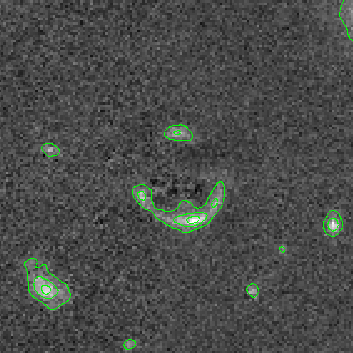

### Chain plot

Removed no burn in


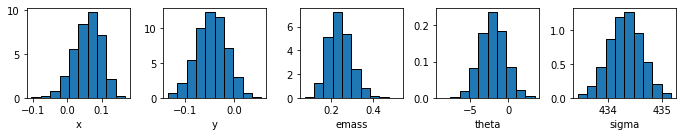

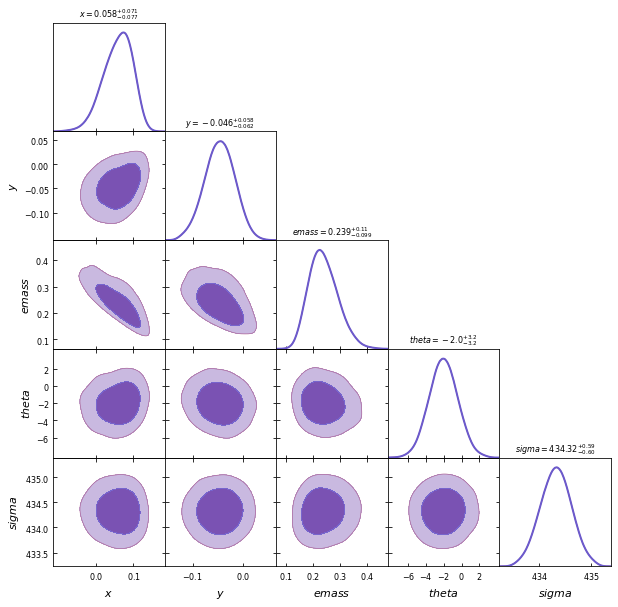

In [5]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_1/", hist_latex_names)

### Anna results for CS82SL013639.16+000818.38

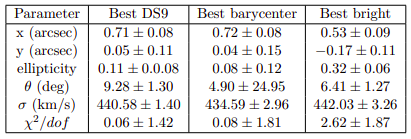

In [6]:
# proposed image positions
input_file = pd.DataFrame({"RA":[24.1631451, 24.1624011, 24.1628248, 24.1638961], "DEC":[0.1384420, 0.1379414, 0.1376109, 0.1381216]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


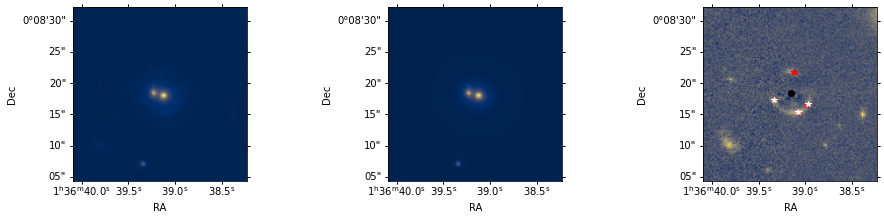

In [7]:
# call the plot function
image_prediction("imgblock1.fits", input_file, "./LOG/sys_1/")

# CS82SL015824.81-003959.60

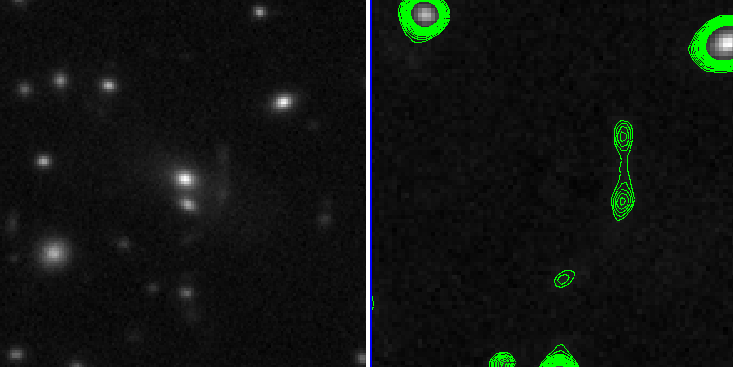

### Chain plot

Removed no burn in


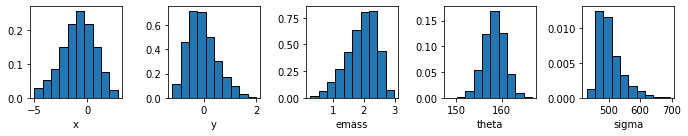

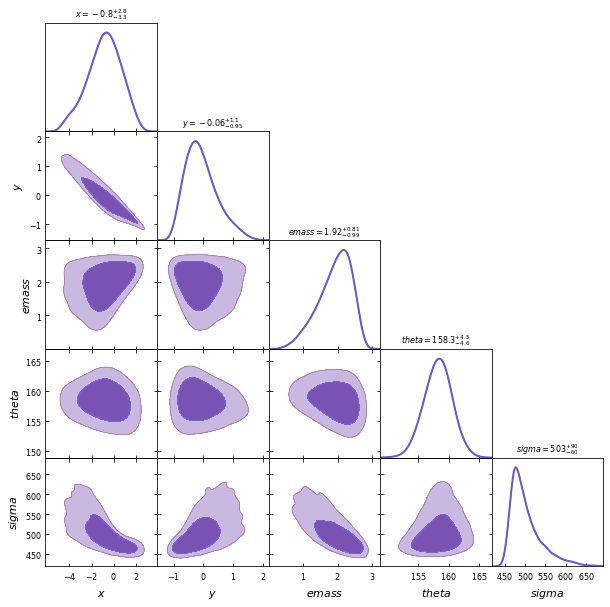

In [8]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_2/", hist_latex_names)

### Anna results for CS82SL015824.81-003959.60

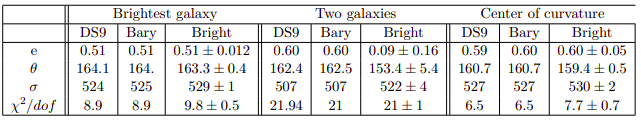

In [10]:
# proposed image positions
input_file = pd.DataFrame({"RA":[29.6033091, 29.6024870, 29.6024954, 29.6032048], "DEC":[-0.6664364, -0.6659979, -0.6667739, -0.6677084]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


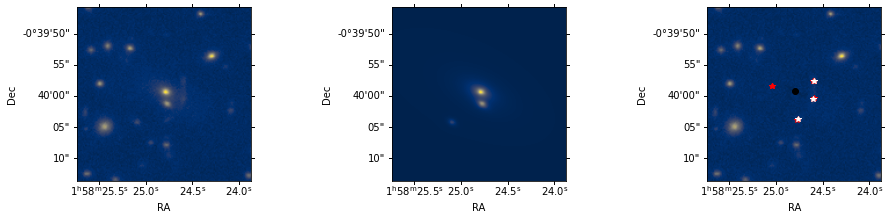

In [11]:
# call the plot function
image_prediction("imgblock2.fits", input_file, "./LOG/sys_2/")

### CS82SL015824.81-003959.60 with fixed positions

Removed no burn in


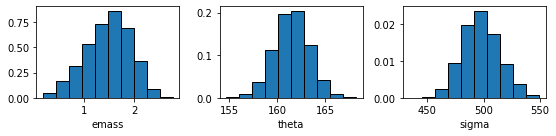

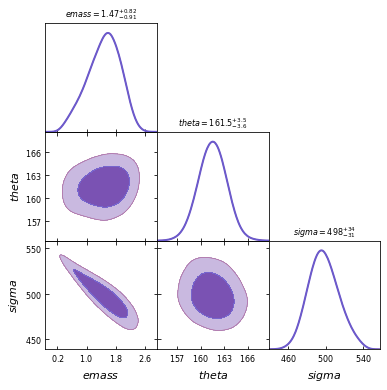

In [13]:
hist_latex_names = ["Nsample", "ln", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_2_fixed_pos/", hist_latex_names)

### Anna results for CS82SL015824.81-003959.60

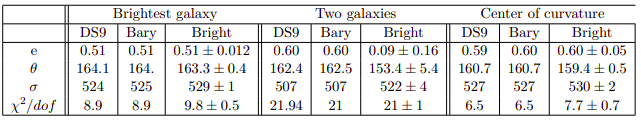

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


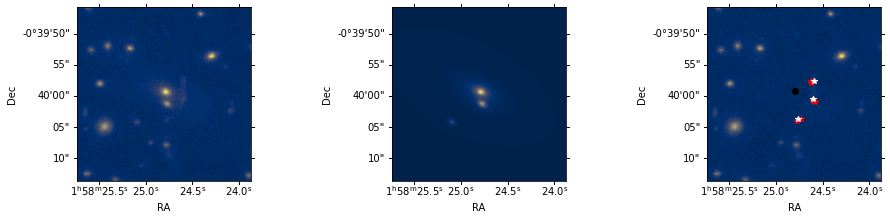

In [14]:
# call the plot function
image_prediction("imgblock2.fits", input_file, "./LOG/sys_2_fixed_pos/")